In [6]:
import numpy as np

np.random.seed(42)
m = 100
X = np.empty((m, 3))
X[:, 0] = np.random.rand(m) * 2 - 1
X[:, 1] = np.random.rand(m) * 2 - 1
X[:, 2] = 2 * X[:, 0] + 3 * X[:, 1] + np.random.randn(m) * 0.1

X_centered = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_centered)

c1 = Vt.T[:, 0]
c2 = Vt.T[:, 1]

In [7]:
print("First Principal Component (c1):", c1)
print("Second Principal Component (c2):", c2)

First Principal Component (c1): [0.14507956 0.22218185 0.964151  ]
Second Principal Component (c2): [-8.37244244e-01  5.46829110e-01 -2.95378654e-05]


In [8]:
W2 = Vt.T[:, :2]

X2D = X_centered.dot(W2)

print("Original dataset shape:", X.shape)
print("Reduced dataset shape:", X2D.shape)
print("\nFirst 3 rows of the new 2D dataset:\n", X2D[:3])

Original dataset shape: (100, 3)
Reduced dataset shape: (100, 2)

First 3 rows of the new 2D dataset:
 [[-3.37792691 -0.34983956]
 [ 2.86787958 -0.6531719 ]
 [-0.03940201 -0.6390619 ]]


In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X2D_sklearn = pca.fit_transform(X)

print("Reduced dataset shape (Scikit-Learn):", X2D_sklearn.shape)

c1_sklearn = pca.components_[0]
c2_sklearn = pca.components_[1]

print("\nFirst PC (Scikit-Learn):", c1_sklearn)

Reduced dataset shape (Scikit-Learn): (100, 2)

First PC (Scikit-Learn): [0.14507956 0.22218185 0.964151  ]


In [10]:
ratios = pca.explained_variance_ratio_

print(f"Variance held by PC1: {ratios[0]:.4f} ({ratios[0]*100:.2f}%)")
print(f"Variance held by PC2: {ratios[1]:.4f} ({ratios[1]*100:.2f}%)")
print(f"Total information preserved: {ratios.sum()*100:.2f}%")

Variance held by PC1: 0.9293 (92.93%)
Variance held by PC2: 0.0706 (7.06%)
Total information preserved: 99.99%


Original dimensions: 10
Dimensions kept for 95% variance: 10


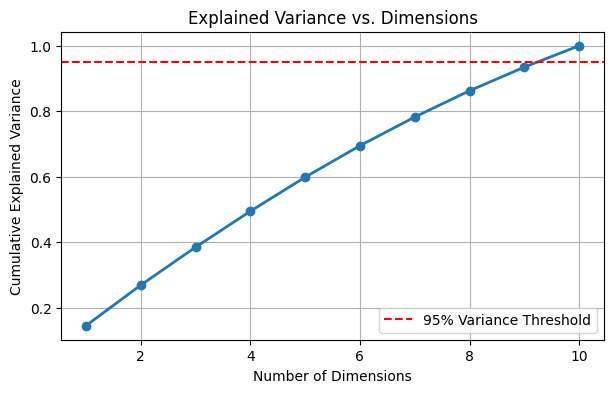

In [11]:
import matplotlib.pyplot as plt

np.random.seed(42)
X_high_dim = np.random.randn(200, 10)

pca_auto = PCA(n_components=0.95)
X_reduced_auto = pca_auto.fit_transform(X_high_dim)

print(f"Original dimensions: {X_high_dim.shape[1]}")
print(f"Dimensions kept for 95% variance: {pca_auto.n_components_}")

pca_full = PCA()
pca_full.fit(X_high_dim)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(cumsum) + 1), cumsum, marker='o', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.xlabel("Number of Dimensions")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs. Dimensions")
plt.legend()
plt.grid(True)
plt.show()

Original X_train shape: (60000, 784)
Reduced shape (Compressed): (60000, 154)
Recovered shape (Decompressed): (60000, 784)


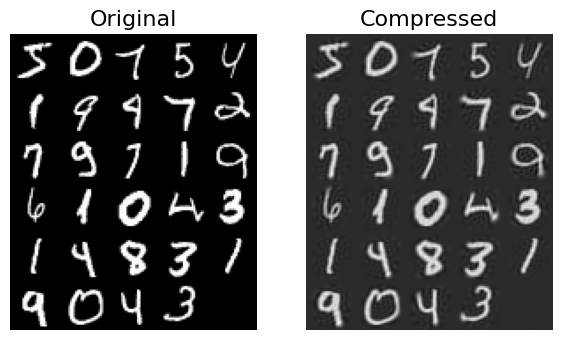

In [12]:
from sklearn.datasets import fetch_openml

print("Downloading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist["data"], mnist["target"]

X_train = X[:60000]
print(f"Original X_train shape: {X_train.shape}")

pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_train)
print(f"Reduced shape (Compressed): {X_reduced.shape}")

X_recovered = pca.inverse_transform(X_reduced)
print(f"Recovered shape (Decompressed): {X_recovered.shape}")

def plot_digits(instances, images_per_row=5, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    images = [instance.reshape(size,size) for instance in instances]
    n_rows = (len(instances) - 1) // images_per_row + 1
    row_images = []
    n_empty = n_rows * images_per_row - len(instances)
    images.append(np.zeros((size, size * n_empty)))
    for row in range(n_rows):
        rimages = images[row * images_per_row : (row + 1) * images_per_row]
        row_images.append(np.concatenate(rimages, axis=1))
    image = np.concatenate(row_images, axis=0)
    plt.imshow(image, cmap="gray", **options)
    plt.axis("off")

plt.figure(figsize=(7, 4))
plt.subplot(121)
plot_digits(X_train[::2100])
plt.title("Original", fontsize=16)
plt.subplot(122)
plot_digits(X_recovered[::2100])
plt.title("Compressed", fontsize=16)
plt.show()

In [13]:
rnd_pca = PCA(n_components=154, svd_solver="randomized")
X_reduced = rnd_pca.fit_transform(X_train)

In [14]:
from sklearn.decomposition import IncrementalPCA

n_batches = 100
inc_pca = IncrementalPCA(n_components=154)

for X_batch in np.array_split(X_train, n_batches):
    inc_pca.partial_fit(X_batch)

X_reduced = inc_pca.transform(X_train)

In [15]:
#X_mm = np.memmap(filename, dtype="float32", mode="readonly", shape=(m, n))

#batch_size = m // n_batches

#inc_pca = IncrementalPCA(n_components=154, batch_size=batch_size)
#inc_pca.fit(X_mm)

In [16]:
#from sklearn.decomposition import KernelPCA

#rbf_pca = KernelPCA(n_components=2, kernel="rbf", gamma=0.04)
#X_reduced = rbf_pca.fit_transform(X)

In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.decomposition import KernelPCA
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=200, n_features=3, n_informative=2, 
                           n_redundant=0, random_state=42)

clf = Pipeline([
    ("kpca", KernelPCA(n_components=2)),
    ("log_reg", LogisticRegression())
])

param_grid = [{
    "kpca__gamma": np.linspace(0.03, 0.05, 10),
    "kpca__kernel": ["rbf", "sigmoid"]
}]

print("Training GridSearchCV... (Finding best parameters)")
grid_search = GridSearchCV(clf, param_grid, cv=3)
grid_search.fit(X, y)

print("\nBest Parameters Found:")
print(grid_search.best_params_)

Training GridSearchCV... (Finding best parameters)

Best Parameters Found:
{'kpca__gamma': np.float64(0.03), 'kpca__kernel': 'sigmoid'}


In [18]:
from sklearn.metrics import mean_squared_error

rbf_pca = KernelPCA(n_components=2, kernel="rbf", gamma=0.0433,
                    fit_inverse_transform=True)

X_reduced = rbf_pca.fit_transform(X)

X_preimage = rbf_pca.inverse_transform(X_reduced)

error = mean_squared_error(X, X_preimage)
print(f"Reconstruction Pre-image Error: {error:.4f}")

Reconstruction Pre-image Error: 0.5417


In [19]:
from sklearn.manifold import LocallyLinearEmbedding

lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10)
X_reduced = lle.fit_transform(X)